In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Path to your local dataset folder
RAW_DATA_PATH = "../dataset"
PROCESSED_DATA_PATH = "../processed_data"

if os.path.exists(RAW_DATA_PATH):
    class_names = [d for d in os.listdir(RAW_DATA_PATH) if os.path.isdir(os.path.join(RAW_DATA_PATH, d))]
    print("✅ Success: Dataset folder found!")
    print(f"Total plant classes detected: {len(class_names)}")
    print(f"Sample classes: {class_names[:3]}")
else:
    print("❌ ERROR: Could not find the 'dataset' folder. Please check your path alignment.")

✅ Success: Dataset folder found!
Total plant classes detected: 2
Sample classes: ['PlantVillage', 'PlantVillage_5Class']


In [6]:
# --- PATH CORRECTION FOR PRE-SPLIT STRUCTURES ---
TRAIN_DIR = "../dataset/PlantVillage_5Class/train"
VAL_DIR   = "../dataset/PlantVillage_5Class/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("🔄 Loading pre-separated dataset structure...")

# 1. Load Training dataset directly from the 'train' folder
ds_train = image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# 2. Load the companion partition directly from the 'val' folder
ds_remainder = image_dataset_from_directory(
    VAL_DIR,
    shuffle=True,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# 3. Split the companion partition 50/50 to generate the validation and testing sets
remainder_batches = tf.data.experimental.cardinality(ds_remainder).numpy()
half_batches = remainder_batches // 2

ds_val = ds_remainder.take(half_batches)
ds_test = ds_remainder.skip(half_batches)

# Capture the accurate plant subspecies string tags
class_names = ds_train.class_names

print("\n--- ✅ FIXED PIPELINE METRICS ---")
print(f"Actual Plant Classes Detected ({len(class_names)}): {class_names}")
print(f"Training Dataset   : {tf.data.experimental.cardinality(ds_train).numpy()} batches")
print(f"Validation Dataset : {tf.data.experimental.cardinality(ds_val).numpy()} batches")
print(f"Testing Dataset    : {tf.data.experimental.cardinality(ds_test).numpy()} batches")

🔄 Loading pre-separated dataset structure...
Found 4268 files belonging to 5 classes.
Found 1068 files belonging to 5 classes.

--- ✅ FIXED PIPELINE METRICS ---
Actual Plant Classes Detected (5): ['Apple___Apple_scab', 'Apple___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Tomato___Late_blight']
Training Dataset   : 134 batches
Validation Dataset : 17 batches
Testing Dataset    : 17 batches


In [7]:
# Scale pixel arrays down from [0,255] to [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

ds_train = ds_train.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
ds_val = ds_val.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
ds_test = ds_test.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

print("⚡ Pixel standardization complete. Data prefetched to runtime memory.")

⚡ Pixel standardization complete. Data prefetched to runtime memory.


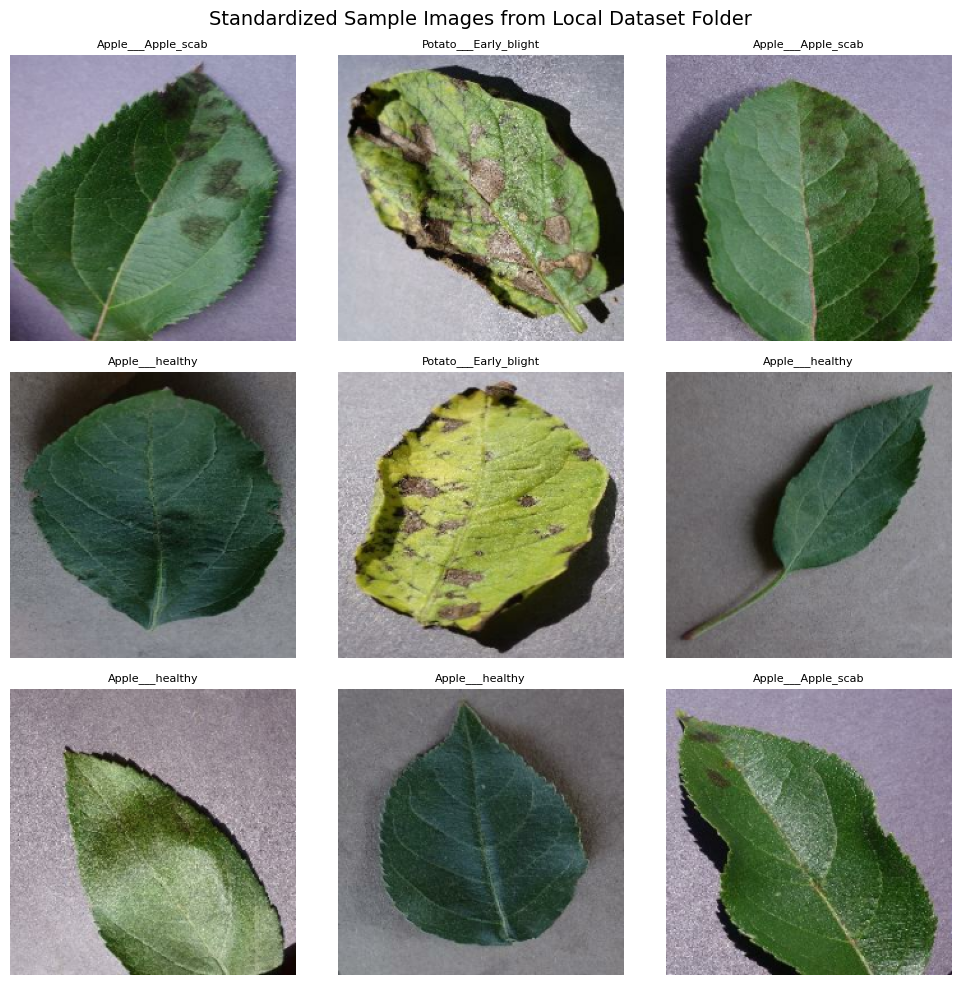

In [10]:
plt.figure(figsize=(10, 10))

# Hardcode the verified list of your 5 classes directly
dataset_classes = [
    'Apple___Apple_scab', 
    'Apple___healthy', 
    'Potato___Early_blight', 
    'Potato___healthy', 
    'Tomato___Late_blight'
]

# Take 1 batch from the training dataset
for images, labels in ds_train.take(1):
    images_in_batch = len(images)
    num_to_plot = min(9, images_in_batch)
    
    for i in range(num_to_plot):
        ax = plt.subplot(3, 3, i + 1)
        
        # If you already normalized to [0, 1] in Cell 4, we multiply by 255 
        # to restore the integer range for a crisp, bright matplotlib display
        img_array = images[i].numpy()
        if img_array.max() <= 1.0:
            img_array = img_array * 255.0
            
        plt.imshow(img_array.astype("uint8"))
        
        # Map the integer label to your hardcoded class name string safely
        class_idx = labels[i].numpy()
        plt.title(dataset_classes[class_idx], fontsize=8)
        plt.axis("off")
        
plt.suptitle("Standardized Sample Images from Local Dataset Folder", fontsize=14)
plt.tight_layout()  
plt.show()

In [11]:
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print("💾 Saving processed datasets to disk... Please wait.")
tf.data.Dataset.save(ds_train, os.path.join(PROCESSED_DATA_PATH, 'train'))
tf.data.Dataset.save(ds_val, os.path.join(PROCESSED_DATA_PATH, 'val'))
tf.data.Dataset.save(ds_test, os.path.join(PROCESSED_DATA_PATH, 'test'))

print(f"🎉 Success! Data files fully exported to: {PROCESSED_DATA_PATH}")

💾 Saving processed datasets to disk... Please wait.
🎉 Success! Data files fully exported to: ../processed_data
